In [1]:
import os
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

path = Path(kagglehub.dataset_download("marquis03/fruits-100"))
filename_names = path / "classname.txt"
filename_train = path / "train.csv"
filename_test = path / "test.csv"
filename_vali = path / "val.csv"


# load data
def take_fruit_names(filename):
    fruit_names = {}
    fruit_id  = 0
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            fruit_name = parts[0]
            fruit_names[fruit_id] = fruit_name
            fruit_id += 1            
    return fruit_names


def load_data_fruit_paths(path):
   image_paths = []
   with open(path, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in reader:
            image_paths.append(row[0])
   return image_paths

def load_data_fruit_category(path):
   image_category = []
   with open(path, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in reader:
            image_category.append(row[1])
   return image_category

fruit_names = take_fruit_names(filename_names)

# train
train_image_paths = load_data_fruit_paths(filename_train)
train_image_category = load_data_fruit_category(filename_train)

# validation
vali_image_paths = load_data_fruit_paths(filename_vali)
vali_image_category = load_data_fruit_category(filename_vali)

# test
test_image_paths = load_data_fruit_paths(filename_test)
print("OK");

2025-12-03 19:48:36.098645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764791316.345335      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764791316.416778      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

OK


# Train EDA

**Display basic information about the dataset**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

number_classes = {}
for label in train_image_category:
    if label in number_classes:
        number_classes[label] += 1
    else:
        number_classes[label] = 1
new_number_classes = {}

for key_number_classes in number_classes:
    for key_fruit_names in fruit_names:
        if(int(key_number_classes) == int(key_fruit_names)):
            new_number_classes[ fruit_names[key_fruit_names] ] = number_classes[key_number_classes] 

print(f"Η κάθε κλάση έχει {len(new_number_classes)}")
plt.figure(figsize=(10, 20))
plt.barh(list(new_number_classes.keys()), list(new_number_classes.values()))
plt.xlabel('# Images')
plt.ylabel('Class Name')
plt.title('Number of Images by Class')
plt.show()

**Visualize sample images from each class**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

dict_train_images = {}
for img_path, label in zip(train_image_paths, train_image_category):
    full_path = path / img_path
    try:
        if full_path.exists():
            with Image.open(full_path) as img:
                category_name = fruit_names[int(label)]
                if category_name not in dict_train_images:
                    dict_train_images[category_name] = []
                dict_train_images[category_name].append(img.copy())

        else:
            print(f"Δεν βρέθηκε: {full_path}")

    except Exception as e:
        print(f"Error loading image {full_path}: {e}")

for category, images in dict_train_images.items():
    if len(images) == 0:
        continue

    img = random.sample(images,8)

    plt.figure(figsize=(10, 6))

    for i, image in enumerate(img):
        plt.subplot(2, 4, i + 1)
        plt.imshow(image)
        plt.axis('off')

    plt.suptitle(f"Category: {category}", fontsize=16)
    plt.tight_layout()
    plt.show() 

**Check for class imbalance**

In [ ]:
num_max = max(new_number_classes.values())
num_min = min(new_number_classes.values())
if num_min != num_max:
    print("Alert Imbalance")
else:
    print("OK")

**Analyze image dimensions**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

directory_train = path/"train" 
dims_dict = {}

for i in range(len(train_image_category)):
    Path = path/train_image_paths[i]
    if Path.exists():
        with Image.open(Path) as img:
            width, height = img.size
            category_name = fruit_names[int(train_image_category[i])]

        # αν δεν υπάρχει η κατηγορία, φτιάξε λίστα
        if category_name not in dims_dict:
            dims_dict[category_name] = []

        # πρόσθεσε νέα διάσταση στη λίστα
        dims_dict[category_name].append((width, height))    
    else:
        print(f"Δεν βρέθηκε: {path}")

widths = [d[0] for dims in dims_dict.values() for d in dims]
heights = [d[1] for dims in dims_dict.values() for d in dims]

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Scatter plot of image sizes (all categories)")
plt.show()    

for category, dims in dims_dict.items():
    
    # χωρίζουμε τα (width, height)
    widths = [d[0] for d in dims]
    heights = [d[1] for d in dims]

    plt.figure()
    plt.scatter(widths, heights)
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.title(f"Image sizes for {category}")
    plt.show()


**Identify and handle any corrupted images**

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

print("Έλεγχος για κατεστραμμένη εικόνα")
for category, images in dict_train_images.items():
    new_images = []
    for img in images:
        try:
            img.verify()  # Έλεγχος αν η εικόνα είναι κατεστραμμένη
            img.load()    # Φορτώνει την εικόνα
            new_images.append(img)
        except Exception:
            print(f"Κατεστραμμένη εικόνα στην κατηγορία '{category}' αφαιρέθηκε.")
            plt.imshow(img)  # Δείχνει την κατεστραμμένη εικόνα
            plt.show()
    dict_train_images[category] = new_images
print("ok")

# Validation EDA

**Display basic information about the dataset**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

number_classes_vali = {}
for label in vali_image_category:
    if label in number_classes_vali:
        number_classes_vali[label] += 1
    else:
        number_classes_vali[label] = 1
new_number_classes_vali = {}

for key_number_classes_vali in number_classes_vali:
    for key_fruit_names_vali in fruit_names:
        if(int(key_number_classes_vali) == int(key_fruit_names_vali)):
            new_number_classes_vali[ fruit_names[key_fruit_names_vali] ] = number_classes_vali[key_number_classes_vali] 

print(f"Η κάθε κλάση έχει {len(new_number_classes_vali)}")
plt.figure(figsize=(10, 20))
plt.barh(list(new_number_classes_vali.keys()), list(new_number_classes_vali.values()))
plt.xlabel('# Images')
plt.ylabel('Class Name')
plt.title('Number of Images by Class')
plt.show()

**Visualize sample images from each class**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

dict_vali_images = {}
for img_path, label in zip(vali_image_paths, vali_image_category):
    full_path = path / img_path
    try:
        if full_path.exists():
            with Image.open(full_path) as img:
                category_name = fruit_names[int(label)]
                if category_name not in dict_vali_images:
                    dict_vali_images[category_name] = []
                dict_vali_images[category_name].append(img.copy())

        else:
            print(f"Δεν βρέθηκε: {full_path}")

    except Exception as e:
        print(f"Error loading image {full_path}: {e}")

for category, images in dict_vali_images.items():
    if len(images) == 0:
        continue

    img = random.sample(images,8)

    plt.figure(figsize=(10, 6))

    for i, image in enumerate(img):
        plt.subplot(2, 4, i + 1)
        plt.imshow(image)
        plt.axis('off')

    plt.suptitle(f"Category: {category}", fontsize=16)
    plt.tight_layout()
    plt.show() 

**Check for class imbalance**

In [ ]:
num_max_vali = max(new_number_classes_vali.values())
num_min_vali = min(new_number_classes_vali.values())
if num_max_vali != num_min_vali:
    print("Alert Imbalance")
else:
    print("OK")

**Analyze image dimensions**

In [ ]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

directory_vali = path/"val" 
dims_dict_vali = {}

for i in range(len(vali_image_category)):
    Path = path/vali_image_paths[i]
    if Path.exists():
        with Image.open(Path) as img:
            width, height = img.size
            category_name = fruit_names[int(vali_image_category[i])]

        # αν δεν υπάρχει η κατηγορία, φτιάξε λίστα
        if category_name not in dims_dict_vali:
            dims_dict_vali[category_name] = []

        # πρόσθεσε νέα διάσταση στη λίστα
        dims_dict_vali[category_name].append((width, height))    
    else:
        print(f"Δεν βρέθηκε: {path}")

widths = [d[0] for dims in dims_dict_vali.values() for d in dims]
heights = [d[1] for dims in dims_dict_vali.values() for d in dims]

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Scatter plot of image sizes (all categories)")
plt.show()    

for category, dims in dims_dict_vali.items():
    
    # χωρίζουμε τα (width, height)
    widths = [d[0] for d in dims]
    heights = [d[1] for d in dims]

    plt.figure()
    plt.scatter(widths, heights)
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.title(f"Image sizes for {category}")
    plt.show()


**Identify and handle any corrupted images**

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

print("Έλεγχος για κατεστραμμένη εικόνα")
for category, images in dict_vali_images.items():
    new_images = []
    for img in images:
        try:
            img.verify()  # Έλεγχος αν η εικόνα είναι κατεστραμμένη
            img.load()    # Φορτώνει την εικόνα
            new_images.append(img)
        except Exception:
            print(f"Κατεστραμμένη εικόνα στην κατηγορία '{category}' αφαιρέθηκε.")
            plt.imshow(img)  # Δείχνει την κατεστραμμένη εικόνα
            plt.show()
    dict_vali_images[category] = new_images
print("ok")

# Test EDA 

**Display basic information about the dataset**

In [5]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
from kagglehub import KaggleDatasetAdapter

number_image_test = []
for img_path in test_image_paths:
    full_path = path / img_path
    try:
        if full_path.exists():
            with Image.open(full_path) as img:
                number_image_test.append(img.copy())
        else:
            print(f"Δεν βρέθηκε: {full_path}")

    except Exception as e:
        print(f"Error loading image {full_path}: {e}")
print(f"Το μέγεθος του test είναι: {len(number_image_test)}")

Το μέγεθος του test είναι: 5000


**Visualize sample images from each class**

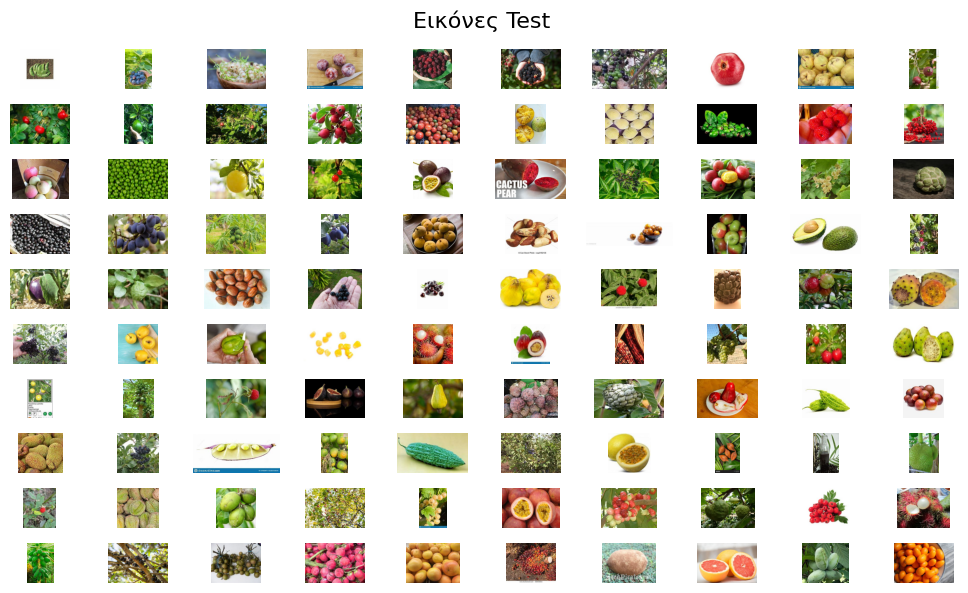

In [18]:
import random
images = random.sample(number_image_test, 100)

plt.figure(figsize=(10, 6))

for i, image in enumerate(images):
    plt.subplot(10, 10, i + 1)
    plt.imshow(image)
    plt.axis('off')
plt.suptitle("Εικόνες Test", fontsize=16)
plt.tight_layout()
plt.show() 

**Analyze image dimensions**

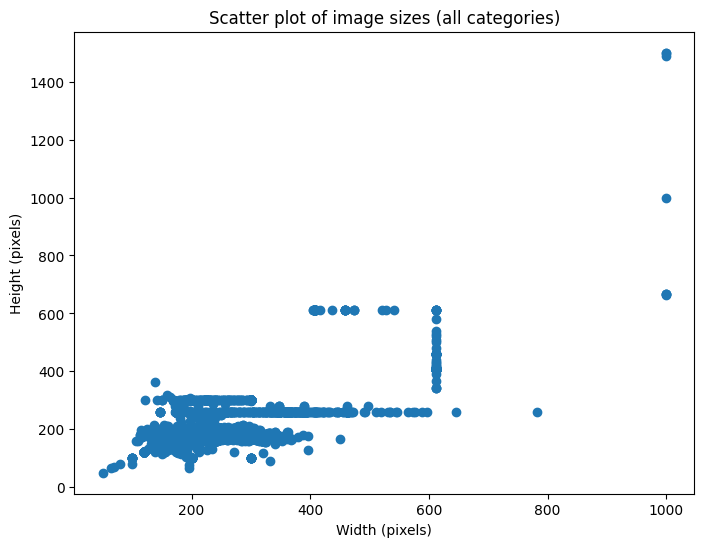

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

dims_dict_test = []
for img in number_image_test:
    width, height = img.size
    dims_dict_test.append((width, height))
widths = [dims[0] for dims in dims_dict_test]
heights = [dims[1] for dims in dims_dict_test]

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Scatter plot of image sizes (all categories)")
plt.show() 
    

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

print("Έλεγχος για κατεστραμμένες εικόνες...")

new_number_image_test = []

for i, img in enumerate(number_image_test):
    try:
        img.load()
        new_number_image_test.append(img)
    except Exception as e:
        print(f"Κατεστραμμένη εικόνα στην θέση {i}")
        plt.imshow(img)
        plt.axis("off")
        plt.show()
print("OK")

Έλεγχος για κατεστραμμένες εικόνες...
OK
